# Neural Networks

### Use the pytorch package to implement a basic neural network that inputs some data (i.e., from your research), and outputs some parameters (e.g., classification or prediction of some value). Train this neural network using some training data, and validate it using a test set. Use plots to discuss your result

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader
f = h5py.File("/Users/relativelyquantum/Programmation/Jupyter/Homework1/Galaxy10_DECals.h5", "r")
galaxy = f["images"]
indx_class = f["ans"]

In [2]:
batch_size = 20  # In order to feed all the data at once, we sent small subset of data in each iteration
number_image_training = 3000
random_galaxy = np.random.choice(17736, size=number_image_training, replace=False)

index_galaxy_training = []
label_galaxy_training = []
def category(index_class):     # Function from homework 1 who categorize de real class from galadxy 10, into one of my 3 category.
    if index_class in [0]:
        return 0 
    if index_class in [1]:
        return 1 
    if index_class in [2,3,4]:
        return 2
    if index_class in [5,6,7]:
        return 3
    if index_class in [8,9]:
        return 4

for i in random_galaxy:
    index_galaxy_training.append(i)
    label_galaxy_training.append(category(int(indx_class[i])))
classes = ['Disturbed','Merging','Round', 'Spiral', 'Bulge']

### After this point we will closely follow the exemple the convolution NN example presented in [1].

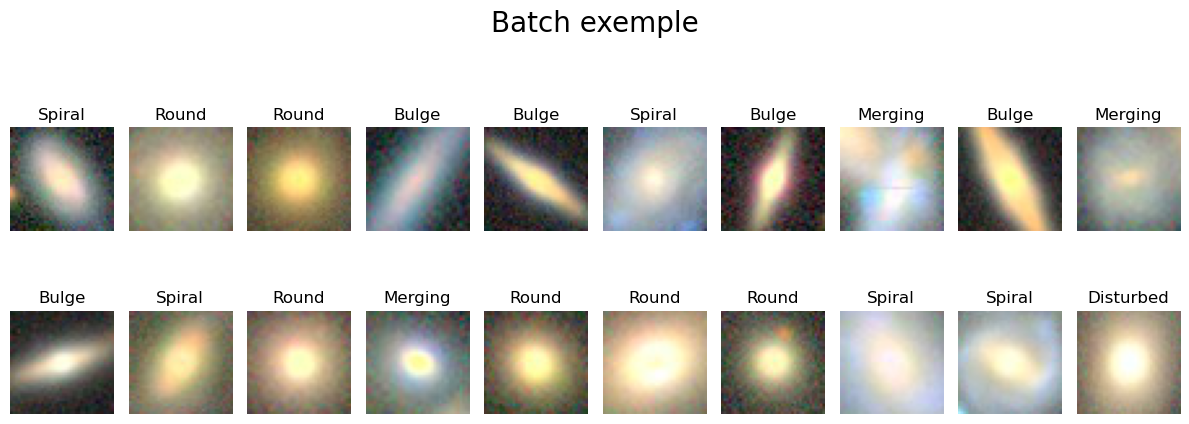

In [3]:
galaxy_transform = transforms.Compose([
    transforms.ToTensor(), # .ToTensor take my image into a tensor PyTorchcan read
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) #.Normalize ajuste the mean and the standars deviation of
])                                                         # the colors band to be 0.5

index_array = np.array(index_galaxy_training)
label_array = np.array(label_galaxy_training)

sort_order = np.argsort(index_array) # If my index are not in order it does not work
sorted_indices = index_array[sort_order]
sorted_labels = label_array[sort_order]


training_set = galaxy[sorted_indices, 108:148, 108:148, :] # we defined the training set and lebel
training_labels_mapped = sorted_labels

train_images = np.array([galaxy_transform(img) for img in training_set])
train_images_tensor = torch.stack([torch.tensor(img) for img in train_images])
train_labels_tensor = torch.tensor(training_labels_mapped, dtype=torch.long)


train_dataset = TensorDataset(train_images_tensor, train_labels_tensor)  # We follow step 3 of the exemple
trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


dataiter = iter(trainloader) # Loading a Batch of Training Images:
images, labels = next(dataiter) 

plt.figure(figsize=(12, 5))
for i in range(batch_size):  # We will visualize a batch exemple
    plt.subplot(2, int(batch_size / 2), i + 1)
    img = images[i]
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.title(classes[labels[i]])

plt.suptitle('Batch exemple', size=20)
plt.tight_layout()
plt.show()

In [4]:
class Net(nn.Module): # This is the neural network function
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) #Take as input the color chanel, output 6 filter 5x5
        self.pool = nn.MaxPool2d(2, 2) #Reduce the spatial dimensions
        self.conv2 = nn.Conv2d(6, 16, 5) # Second Layer, again ( input,output,kernel size)
        self.fc1 = nn.Linear(16 * 7 * 7, 120)  
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 5)             # 5 classes

    def forward(self, x):  #  Transforming the image from raw pixels into a final classification.
        x = self.pool(F.relu(self.conv1(x))) #  extract basic patterns from covolution 1 then 2. It's pass it trought the
        x = self.pool(F.relu(self.conv2(x))) # activation function ( relu)
        x = torch.flatten(x, 1) # We put the image in 1D
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x) # Output scores each galaxy class 
        return x
net = Net()

In [5]:
criterion = nn.CrossEntropyLoss() # This is our loss function
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # The optimizer update the model’s parameters 

In [6]:
# Training phase
for epoch in range(100):  # We chose to go 100 thrue the data set
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        optimizer.zero_grad()   # Reset gradient 

        outputs = net(inputs)   # We sent the data into our NN function
        loss = criterion(outputs, labels)   
        loss.backward()         
        optimizer.step()        # Update the model’s parameters (We uptated the weight)


In [7]:
# We saved the model so we don't have to retrain it the next time we want to use it
PATH = './galaxy_net.pth'
torch.save(net.state_dict(), PATH)


In [8]:
# Test set
test_set_size = 1000
random_galaxy_test = np.random.choice(17736, size=test_set_size, replace=False)
index_galaxy_testing = []
label_galaxy_testing = []
for i in random_galaxy_test:
    index_galaxy_testing.append(i)
    label_galaxy_testing.append(category(indx_class[i]))

test_index_array = np.array(index_galaxy_testing, dtype=int)
test_label_array = np.array(label_galaxy_testing, dtype=int)

sort_order = np.argsort(test_index_array) # We need to sort the data to avoid errors
sorted_test_indices = test_index_array[sort_order]
sorted_test_labels = test_label_array[sort_order]

testing_set = galaxy[sorted_test_indices, 108:148, 108:148, :]
test_images = np.array([galaxy_transform(img) for img in testing_set])
test_images_tensor = torch.stack([torch.tensor(img) for img in test_images]) # Convert the labels and images in pytorch tensor
test_labels_tensor = torch.tensor(sorted_test_labels, dtype=torch.long)

# We set up the streamline to process the test images in the model
test_dataset = TensorDataset(test_images_tensor, test_labels_tensor)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)


In [9]:
dataiter = iter(testloader) # We select a batch of images from the test 
images, labels = next(dataiter)


net = Net()
net.load_state_dict(torch.load(PATH)) # load the saved the model parameters
net.eval()  


outputs = net(images) # Output of the model
_, predicted = torch.max(outputs, 1)# Select the class with the highest score for each images.
                                    #This produce an array of predicted labels.



In [10]:
# Evaluation
net.eval()  
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: Disturbed is 39.7 %
Accuracy for class: Merging is 35.8 %
Accuracy for class: Round is 77.8 %
Accuracy for class: Spiral is 84.4 %
Accuracy for class: Bulge is 79.8 %


We can see that our result is is relatively accurate. It makes sense that the least successful class is the “disturbed” class, since it can resemble any other class.

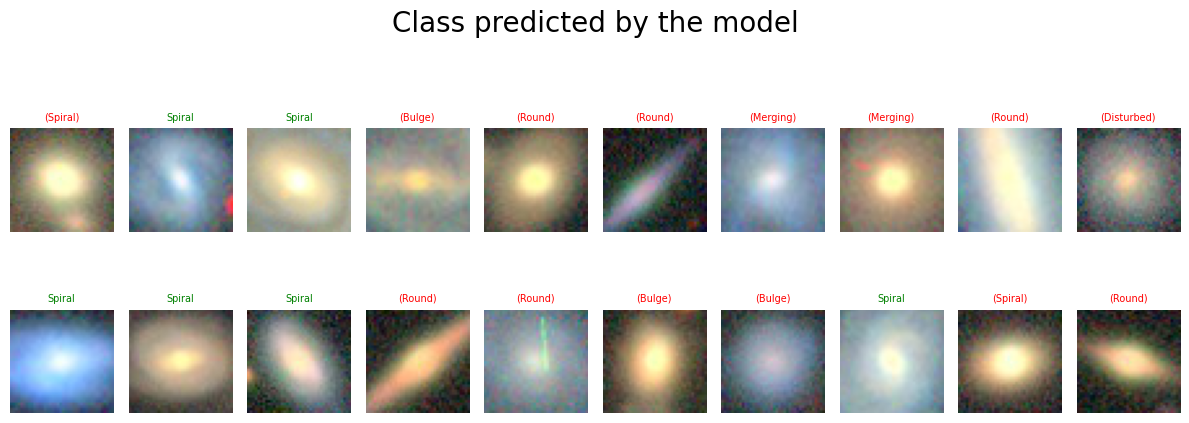

In [11]:
#We print out the images and check the model’s prediction. If the class label is green, the model’s prediction is correct. 
#Otherwise, the label appears in red.
plt.figure(figsize=(12, 5))
for i in range(batch_size):
    plt.subplot(2, int(batch_size / 2), i + 1)
    img = images[i]
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    
    true_label = classes[labels[i].item()]     
    pred_label = classes[predicted[i].item()]  
    
    color = "green" if true_label == pred_label else "red"
    label_text = pred_label if color == "green" else f"({pred_label})"
    
    plt.title(f"{label_text}", color=color, fontsize=7)

plt.suptitle('Class predicted by the model', size=20)
plt.tight_layout()
plt.show()


## Reference :
[1] - https://medium.com/data-bistrot/a-simple-image-classifier-with-a-python-neural-network-82a5522fe48b